## <center> **Анализ результатов A/B-тестирования**

Компания планирует запустить новую акцию, чтобы продать как можно больше туров. Команда разработала два варианта посадочной страницы официального сайта компании и провела A/B-тестирование. Собранные в результате проведения эксперимента данные вы можете найти здесь.

Вам предстоит решить настоящую бизнес-задачу: проанализировать эффективность обоих вариантов посадочной страницы сразу по двум критериям: конверсии покупки и среднему чеку. На основе проведенного анализа вам будет необходимо сделать выводы и принять решение: какой из вариантов дизайна более предпочтительный.

Итак, наша фирма предлагает следующие варианты туров и их соответствующие стоимости:
* Таиланд — 100000 рублей;
* Турция — 60000 рублей;
* Мальдивы — 200000 рублей;
* Санкт-Петербург — 10000 рублей;
* Камчатка — 150000 рублей.

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from scipy.stats import t
from scipy.stats import ttest_ind, shapiro, f_oneway, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest

Прочитаем наши данные и посмотрим на столбцы таблицы:

In [2]:
data = pd.read_csv('data/ab_data_tourist.csv')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


## **Задание 7.1.**

Начнем с исследования структуры наших данных. С помощью метода info() выведите информацию о типах данных и количестве непустых значений. Какой тип данных имеет столбец date?

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   294478 non-null  int64 
 1   date      294478 non-null  object
 2   group     294478 non-null  object
 3   purchase  294478 non-null  int64 
 4   price     294478 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.2+ MB


## **Задание 7.2.**

Приведите столбец date к типу данных datetime. Убедитесь в равной длительности проведения тестирования для каждой из группы. Для этого сгруппируйте данные по признаку группы и определите первую и последнюю дату наблюдения для каждой из групп. 

В какой промежуток времени проводился A/B-тест?


In [4]:
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')

data.groupby('group')['date'].agg(['min', 'max'])

,min,max
group,,
A,2021-01-02,2021-01-24
B,2021-01-02,2021-01-24


## **Задание 7.3.**

* Чему равно количество посещений сайта в группах А и B?

* Чему равно суммарное количество покупок в группах А и B?

* Чему равна сумма всех покупок в группах А и B? Ответ приведите в миллионах рублей. Например, 185.52 млн. руб.

In [5]:
print('Количество посещений сайта')
display(data.groupby('group')['user_id'].agg('count'))
print('----------------')

print('Количество покупок')
display(data.groupby('group')['purchase'].agg('sum'))
print('----------------')

print('Сумма покупок, млн. руб.')
display(data.groupby('group')['price'].agg('sum') / 1000000)

Количество посещений сайта


group
A    147202
B    147276
Name: user_id, dtype: int64

----------------
Количество покупок


group
A    17723
B    17514
Name: purchase, dtype: int64

----------------
Сумма покупок, млн. руб.


group
A    1436.26
B    1554.10
Name: price, dtype: float64

## **Задание 7.4.**

Проверьте, есть ли пользователи, которые в процессе A/B-теста попали в обе тестовые группы? Если да, то сколько таких уникальных пользователей, если нет - введите в поле для ответа 0?

**Подсказка:**

*Создайте множество пользователей группы А и множество пользователей группы B. Пересеките два этих множества (операция intersection) и вычислите количество элементов в полученном множестве.*


In [6]:
# множество пользователей группы А
users_a = set(data[data['group'] == 'A']['user_id'])

# множество пользователей группы B
users_b = set(data[data['group'] == 'B']['user_id'])

# множество пользователей, которые присутствуют в обеих группах
user_intersection = users_a.intersection(users_b)
print('Количество пользователей, которые присутствуют в обеих группах:', len(user_intersection))

Количество пользователей, которые присутствуют в обеих группах: 1895


## **Исключите пользователей, оказавшихся в обеих группах**

Так как мы не можем определить, какая из версий сайта повлияла на принятие решения, исключим этих пользователей. Далее мы будем работать только с очищенными от пересечений данными.

Возможный вариант исключения пользователей:

In [7]:
updated_data = data[data['user_id'].apply(lambda x: x not in user_intersection)]

Где user_intersection - множество пересечений пользователей групп А и B.

## **Задание 7.5.**

Для первичного анализа результатов A/B-тестирования нам понадобится таблица следующего вида:

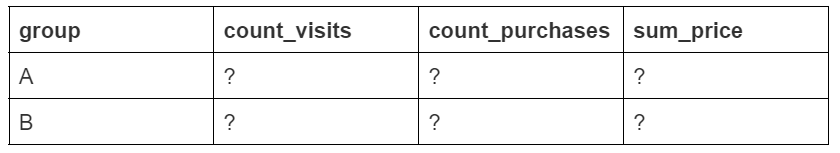
 
 
Для того, чтобы получить такую таблицу, сгруппируйте данные по признаку группы. В каждой группе рассчитайте следующие показатели:
* количество посещений (количество пользователей)
* количество совершенных покупок
* сумма всех покупок в группе

В полученной сгруппированной таблице переименуйте столбцы на **count_visits, count_purchases и sum_price**.

**Подсказка:**

*Для переименования столбцов можно использовать метод rename() с параметром columns, в который передается словарь. Ключи этого словаря - старые имена столбцов, а значения - новые.*

Чему на этот раз равно количество посещений сайта в группах А и B?


In [8]:
group_data = updated_data.groupby('group').agg({
    'user_id': 'count',
    'purchase': 'sum',
    'price': 'sum'
}).rename(columns={
    'user_id': 'count_visits',
    'purchase': 'count_purchases',
    'price': 'sum_price'
})

group_data

,count_visits,count_purchases,sum_price
group,,,
A,145307,17487,1417780000
B,145381,17290,1533010000


Приведите промежуточные выводы по построенной таблице. Сопоставимо ли количество посещений обоих вариантов посадочной странице, можно ли говорить о сбалансированности выборок?

Соотношение количества посещений обоих вариантов посадочных страниц составляет 50 / 50, на основании этого можем сделать вывод о сбалансированности полученных в ходе эксперемента выборок.

## **Задание 7.6.**

Добавьте в сгруппированную таблицу столбцы conversion - конверсия покупки (отношение количества покупок к количеству посещений сайта в каждой группе, выраженное в процентах) и mean_check - средний чек (отношение суммы покупок к количеству покупок в каждой группе).

* Чему равна конверсия в группах? Ответ приведите в процентах и округлите до сотых. Например, 75.12 %
* Чему равен средний чек в группах? Ответ приведите в рублях и округлите до целых. Например, 120519 рублей.

In [9]:
# Рассчитываем конверсию покупки
group_data['conversion'] = round(group_data['count_purchases'] / group_data['count_visits'] * 100, 2)

# Рассчитываем средний чек покупки
group_data['mean_check'] = round(group_data['sum_price'] / group_data['count_purchases'])

group_data

,count_visits,count_purchases,sum_price,conversion,mean_check
group,,,,,
A,145307,17487,1417780000,12.03,81076.0
B,145381,17290,1533010000,11.89,88665.0


Приведите промежуточные выводы по таблице. По какому(им) показателю(ям) вариант А эффективнее варианта B и наоборот?

Из построенной таблицы видим, что в варианте B наблюдается снижение показателя конверсия покупки (разница составляет -0.14 процентых пункта, что соответствует снижению на 1.18 %), при этом наблидается увеличение показателя средний чек (увеличение составляет 7589 руб., 9,36 %)

## **Задание 7.7.**

Теперь давайте сравним варианты по покупательской способности туров. Для этого постройте сводную таблицу, которая покажет зависимость количества продаж от группы и цены тура. 

In [10]:
pivot_data = updated_data.pivot_table(
    values='purchase',
    index='price',
    columns='group',
    aggfunc='sum',
    fill_value=0
)

pivot_data

group,A,B
price,,
0,0,0
10000,5182,5201
60000,5271,1730
100000,1832,5227
150000,3478,3438
200000,1724,1694


Визуализируйте полученную сводную таблицу с помощью тепловой карты с аннотацией. 
Чему равно количество проданных туров за 60000 рублей в группах?

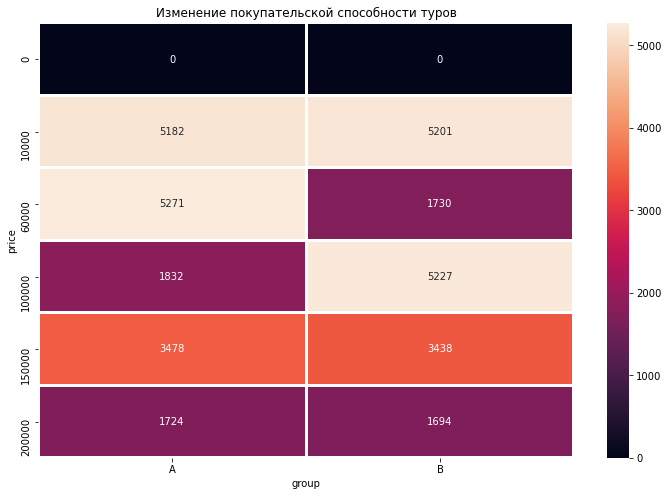

In [11]:
fig = plt.figure(figsize=(12, 8))

heatmap = sns.heatmap(
    pivot_data, 
    annot=True, 
    fmt='g',
    linewidths=2
)
heatmap.set_title('Изменение покупательской способности туров');

Сделайте выводы по построенной таблице. По каким турам покупательская способность участников группы А выше, чем участников группы B и наоборот?

Из построенной сводной таблицы видим, что происходит изменение покупательской способности туров в Турцию и в Тайланд, продажи других туров сопаставимы в обоих группах. При этом общее количество туров, проданных в Турцию и Тайланд, в обоих группах соспоставимо, однако в группе В доминируют продажи более дорогих туров в Тайланд, тогда как в группе А преобладают продажи более дешевых туров в Турцию.

## **Задание 7.8.**

Настало время поговорить о стабилизации кумулятивных метрик во времени. Но прежде, чем перейти к кумулятивным метрикам, нам необходимо построить таблицу с ежедневными данными результатов проведения A/B-тестирования.

Сгруппируйте данные по дате и группе тестирования. В каждой группе вычислите количество посещений страницы, количество покупок и сумму покупок. 

Добавьте в таблицу информацию о ежедневной конверсии (ежедневное количество покупок / ежедневное количество посещений) в группе и ежедневном среднем чеке (ежедневная сумма покупок / ежедневное количество покупок)
* Чему равна конверсия 3 января 2021 года? Ответ приведите в процентах и округлите до сотых.

* Чему равен средний чек 3 января 2021 года? Ответ приведите в рублях и округлите до целого.

In [12]:
daily_data = updated_data.groupby(['date', 'group']).agg({
    'user_id': 'count',
    'purchase': 'sum',
    'price': 'sum'
}).reset_index().rename(columns={
    'user_id': 'count_visits',
    'purchase': 'count_purchases',
    'price': 'sum_price'
})

# Рассчитываем конверсию покупки
daily_data['conversion'] = daily_data['count_purchases'] / daily_data['count_visits'] * 100

# Рассчитываем средний чек покупки
daily_data['mean_check'] = daily_data['sum_price'] / daily_data['count_purchases']

daily_data.head()

,date,group,count_visits,count_purchases,sum_price,conversion,mean_check
0,2021-01-02,A,2854,359,29410000,12.578837,81922.005571
1,2021-01-02,B,2861,345,29660000,12.058721,85971.014493
2,2021-01-03,A,6596,748,62000000,11.340206,82887.700535
3,2021-01-03,B,6619,754,65960000,11.391449,87480.106101
4,2021-01-04,A,6566,799,64250000,12.168748,80413.016270


## **Задание 7.9.** 

Добавьте в таблицу с ежедневными показателями кумулятивные признаки:
* кумулятивное количество посещений страницы
* кумулятивное количество покупок
* кумулятивную сумму покупок

Не забудьте при расчете кумулятивной суммы сгруппировать данные по группам. 

Вычислите кумулятивную конверсию и кумулятивный средний чек на основе полученных кумулятивных показателей. 

* Какая **кумулятивная** конверсия была в группе B на 20 января? Ответ приведите в процентах, округлив до сотых.
* Какой **кумулятивный** средний чек был в группе А на 12 января 2021 года? Ответ приведите в рублях, округлив до целых.

In [13]:
# Рассчитываем кумулятивные показатели
daily_data['cum_visits'] = daily_data.groupby('group')['count_visits']. transform('cumsum')
daily_data['cum_purchases'] = daily_data.groupby('group')['count_purchases']. transform('cumsum')
daily_data['cum_price'] = daily_data.groupby('group')['sum_price']. transform('cumsum')
daily_data['cum_conversion'] = daily_data ['cum_purchases'] / daily_data ['cum_visits'] * 100
daily_data['cum_mean_check'] = daily_data ['cum_price'] / daily_data ['cum_purchases']

daily_data.head()

,date,group,count_visits,count_purchases,sum_price,conversion,mean_check,cum_visits,cum_purchases,cum_price,cum_conversion,cum_mean_check
0,2021-01-02,A,2854,359,29410000,12.578837,81922.005571,2854,359,29410000,12.578837,81922.005571
1,2021-01-02,B,2861,345,29660000,12.058721,85971.014493,2861,345,29660000,12.058721,85971.014493
2,2021-01-03,A,6596,748,62000000,11.340206,82887.700535,9450,1107,91410000,11.714286,82574.525745
3,2021-01-03,B,6619,754,65960000,11.391449,87480.106101,9480,1099,95620000,11.592827,87006.369427
4,2021-01-04,A,6566,799,64250000,12.168748,80413.016270,16016,1906,155660000,11.900599,81668.415530


Постройте кумулятивные графики конверсии и среднего чека в каждой группе по дням. Сделайте выводы. Можно ли назвать A/B-тест завершенным - стабилизировались ли значения метрик во времени? Как соотносятся кумулятивные показатели в каждой группе?

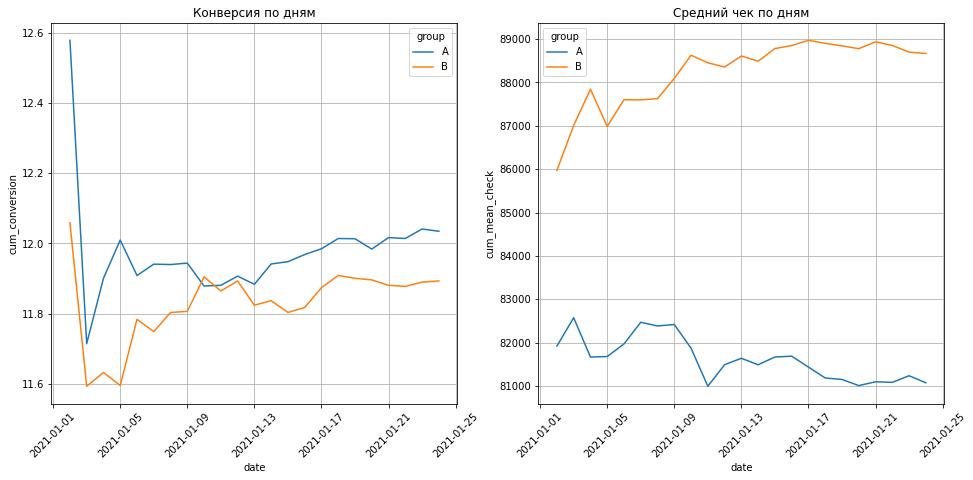

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))

sns.lineplot(
    data=daily_data, 
    y='cum_conversion', 
    x='date',
    ax=axes[0],
    hue='group'
)

sns.lineplot(
    data=daily_data, 
    y='cum_mean_check', 
    x='date',
    ax=axes[1],
    hue='group'
)

axes[0].set_title('Конверсия по дням')
axes[0].xaxis.set_tick_params(rotation=45)
axes[0].grid()

axes[1].set_title('Средний чек по дням')
axes[1].xaxis.set_tick_params(rotation=45)
axes[1].grid();

Из построенных графиков каммулятиных показателей конверсии и среднего чека видим, что с 06 января значения метрик стабилизировались. При этом конверсия в обих группах имеют тенденцию к росту. Однако графики среднего чека разнонаправленные, в группе А наблюдается тенденция к снижению среднего чека, в то время как в группе В устойчивая тенденция к росту среднего чека. На основании изложенного, можем считать А/В тест завершенным.  

## **Задание 7.10.**

Настало время переходить к проверке статистической значимости разницы между метриками в группах. Начнем с конверсии.

Какой тест вы примените для проверки гипотезы о равенстве конверсий в группах?

Проведите тестирование при следующих нулевой и альтернативной гипотезе:
* $H_0$: Конверсии в группах А и B равны; 
* $H_1$: Конверсия в группе А больше чем конверсия в группе B;

Вычислите p-value вашего теста для конверсий в группах А и B. Сравните полученное значение p-value с уровнем значимости $\alpha$=0.05. 

In [15]:
# Формулируем гипотезы.
H0 = 'Конверсии в группах А и B равны'
H1 = 'Конверсия в группе А больше чем конверсия в группе B'

# Уровень значимости.
alpha = 0.05

# Формируем таблицу для расчета значения p-value z-теста для пропорций.
converted_table = updated_data.groupby('group')['purchase'].agg(['sum', 'count'])

# Рассчитываем значение p-value.
s, p_value = proportions_ztest(
    count=converted_table['sum'],
    nobs=converted_table['count'],
    alternative='larger'
)

print('p-value:', round(p_value, 2))

# Сравниваем полученное p-value с уровнем значимости.
if (p_value < alpha): 
    print(f'Отвергаем нулевую гипотезу. {H0}')
    print(f'Альтернативная гипотеза. H1: {H1}')
else:
    print(f'Принимаем нулевую гипотезу. {H0}')

p-value: 0.12
Принимаем нулевую гипотезу. Конверсии в группах А и B равны


Приведите свои выводы по результатам проведенного статистического теста. Есть ли статистическая разница между конверсиями в группах А и B?

В результате проверки гипотезы о равенстве конверсий в группах А и В, выяснили, что отсутствует статистически значимая разница между конверсиями в группах А и В, таким образом принимаем нулевую гипотезу о равенстве конверсий в группах.

## **Задание 7.11.**
Убедитесь в своих рассуждениях, построив 95%-ый доверительный интервал для конверсий и разницы между ними. Используйте $z_{крит}$ в своих расчетах

Укажите нижнюю и верхнюю границы доверительных интервалов. Границы приведите в процентах и округлите до 2 знака после запятой. Например: нижняя граница 89.24%, верхняя граница 91.25%.

In [29]:
def conf_interval(data, gamma=0.95):   
    alpha = 1 - gamma # уровень значимости
    n = data.count() # размер выборки
    k = n - 1 # число степеней свободы
    x_mean = data.mean() # выборочное среднее
    x_std = data.std() # выборочное стандартное отклонение
    t_crit = -t.ppf(alpha/2, k) # t критическое
    eps = t_crit * x_std/(n ** 0.5) #погрешность
    lower_bound = x_mean - eps # левая (нижняя) граница
    upper_bound = x_mean + eps # правая (верхняя) граница
    # возвращаем кортеж из округлённых границ интервала
    return round(lower_bound), round(upper_bound)


def proportions_conf_interval(n, x_p, gamma=0.95):   
    alpha = 1 - gamma # уровень значимости
    z_crit = -norm.ppf(alpha/2) # z критическое
    eps = z_crit * (x_p * (1 - x_p) / n) ** 0.5 #погрешность
    lower_bound = x_p - eps # левая (нижняя) граница
    upper_bound = x_p + eps # правая (верхняя) граница
    # возвращаем кортеж из округлённых границ интервала
    return round(lower_bound * 100, 2), round(upper_bound * 100, 2)


def diff_proportions_conf_interval(n, xp, gamma=0.95):
    alpha = 1 - gamma # уровень значимости
    diff = xp[1] - xp[0] # выборочная разница конверсий групп B и A
    z_crit = -norm.ppf(alpha/2) # z критическое
    eps = z_crit * (xp[0] * (1 - xp[0])/n[0] + xp[1] * (1 - xp[1])/n[1]) ** 0.5 # погрешность
    lower_bound = diff - eps # левая (нижняя) граница
    upper_bound = diff + eps # правая (верхняя) граница
    # возвращаем кортеж из округлённых границ интервала
    return round(lower_bound *100, 2), round(upper_bound * 100, 2)

In [17]:
# Сформируем выборки для каждой группы.
a_updated_data = updated_data[updated_data['group'] == 'A']
b_updated_data = updated_data[updated_data['group'] == 'B']

# Доверительный для группы А.
conf_interval_a = proportions_conf_interval(
    n=a_updated_data['user_id'].count(),
    x_p=a_updated_data['purchase'].mean()
)
print(f'Доверительный интервал для конверсии группы А: {conf_interval_a}')

# Доверительный для группы В.
conf_interval_b = proportions_conf_interval(
    n=b_updated_data['user_id'].count(),
    x_p=b_updated_data['purchase'].mean()
)
print(f'Доверительный интервал для конверсии группы А: {conf_interval_b}')

# Доверительный для разности конверсий групп А и В.
n = [a_updated_data['user_id'].count(), b_updated_data['user_id'].count()]
xp = [a_updated_data['purchase'].mean(), b_updated_data['purchase'].mean()]
diff_inverval = diff_proportions_conf_interval(n, xp)
print(f'Доверительный интервал для разности конверсий: {diff_inverval}')

Доверительный интервал для конверсии группы А: (11.87, 12.2)
Доверительный интервал для конверсии группы А: (11.73, 12.06)
Доверительный интервал для разности конверсий: (-0.38, 0.09)


Проинтерпретируйте построенные доверительные интервалы для конверсий в группах. Есть ли перекрытие между доверительными интервалами для групп? Есть ли статистическая разница между конверсиями в группах А и B?

Из полученных данных, видим, что 95% доверительные интервалы для конверсий в группах А и В перекрывают друг друга, на основании изложенного можно сделать вывод об отсутствие статистически значимой разницы между конверсиями в группах. 
Нижняя граница доверительного интервала для разности конверсий отрицательная, верхняя - положительная, данный факт подтверждает вывод об отсутствие статистически значимой разницы между конверсиями в группах.

## **Задание 7.12.**

Ранее мы построили таблицу с ежедневными показателями. Теперь она нам снова понадобится, так как нас интересует ежедневный средний чек.

Проверьте гипотезу о нормальности распределения ежедневного среднего чека в каждой из групп тестирования. 

* Какой тест вы примените  для проверки гипотезы о нормальности распределения ежедневного среднего чека?
* Как будут звучать нулевая и альтернативная гипотезы?
* Каковы результаты статистического теста с уровнем значимости $\alpha$ =0.05?

In [20]:
# Сформируем ежедневные выборки для каждой группы.
daily_data_a = daily_data[daily_data['group'] == 'A']
daily_data_b = daily_data[daily_data['group'] == 'B']

# Формулируем гипотезы.
H0 = 'Распределения в обеих группах нормальные'
H1 = 'Распределение в одной или обеих группах отлично от нормального'
# Уровень значимости
alpha = 0.05

# Рассчитываем результат теста Шапиро-Уилка для выборок.
shapiro_a = shapiro(daily_data_a['mean_check'])
shapiro_b = shapiro(daily_data_b['mean_check'])

print('p-value в группе А:', round(shapiro_a.pvalue, 2))
print('p-value в группе В:', round(shapiro_b.pvalue, 2))

# Сравниваем полученные p-value с уровнем значимости.
if shapiro_a.pvalue < alpha or shapiro_b.pvalue < alpha:
    print(f'Отвергаем нулевую гипотезу. {H0}')
    print(f'Альтернативная гипотеза. H1: {H1}')
else:
    print(f'Принимаем нулевую гипотезу. {H0}')

p-value в группе А: 0.25
p-value в группе В: 0.09
Принимаем нулевую гипотезу. Распределения в обеих группах нормальные


## **Задание 7.13.**
Настало время сравнить варианты дизайна страницы по метрике среднего чека. 

Какой тест вы примените для проверки гипотезы о равенстве средних чеков по дням в группах?

Проведите тестирование при следующих нулевой и альтернативной гипотезе:
* $H_0$: Ежедневные средние чеки в группах А и B равны; 
* $H_1$: Ежедневный средний чек в группе А меньше чем в группе B;

Вычислите p-value вашего теста для ежедневного среднего чека в группах А и B. Сравните полученное значение p-value с уровнем значимости $\alpha$ =0.05. 

In [32]:
# Формулируем гипотезы.
H0 = 'Ежедневные средние чеки в группах А и B равны'
H1 = 'Ежедневный средний чек в группе А меньше чем в группе B'
# Уровень значимости
alpha = 0.05

# Рассчитываем результат T-теста для ежедневных выборок.
result = ttest_ind(
    a=daily_data_a['mean_check'],
    b=daily_data_b['mean_check'],
    alternative='less'
)

print('p-value:', round(result.pvalue, 2))

if result.pvalue < alpha: 
    print(f'Отвергаем нулевую гипотезу. {H0}')
    print(f'Альтернативная гипотеза. H1: {H1}')
else:
    print(f'Принимаем нулевую гипотезу. {H0}')

p-value: 0.0
Отвергаем нулевую гипотезу. Ежедневные средние чеки в группах А и B равны
Альтернативная гипотеза. H1: Ежедневный средний чек в группе А меньше чем в группе B


 Приведите свои выводы по проведенному статистическому тесту. Есть ли статистическая разница между ежедневными средними чеками в группах А и B?

Проверка гипотезы о равенстве средних чеков отвергнута, таким образом разница в средних чеках в группах статистически значима.

## **Задание 7.14.**

Постройте 95%-ый доверительный интервал для среднего чека в каждой группе. Так как выборка средних чеков небольшая, используйте  $t_{крит}$ в своих расчетах.

Укажите нижнюю границу доверительного интервала для истинного среднего чека каждой из групп. Ответ приведите в процентах и округлите до целого.

In [30]:
# Доверительный для группы А.
conf_interval_check_a = conf_interval(daily_data_a['mean_check'])
print(f'Доверительный интервал для конверсии группы А: {conf_interval_check_a}')

# Доверительный для группы В.
conf_interval_check_b = conf_interval(daily_data_b['mean_check'])
print(f'Доверительный интервал для конверсии группы B: {conf_interval_check_b}')

Доверительный интервал для конверсии группы А: (79630, 82308)
Доверительный интервал для конверсии группы B: (87626, 89526)


Проинтерпретируйте построенные доверительные интервалы для ежедневных средних чеков в группах. Есть ли между ними пересечения?

В результате построения 95% доверительных интервалов, видим, что доверительные интервалы не пересекаются, таким обтазом истинное среднее значение метрики средний чек в группе В больше истинного среднего значения метрики средний чек в группе А. 

## **Сделайте общий вывод по результатам A/B-теста**

Какой варианта дизайна посадочной страницы является более эффективным в комплексе по метрикам конверсии и среднего чека и почему? 

Для оценки нового варианта дизайна посадочной страницы, были проанализированы данные, собранные в ходе А/В тестирования, по показателям конверсия продаж и средний чек.
Анализ показателя конверсия продаж показал, что разница между показателями в группах А и В не является статистической значимой, таким образом мы не можем утверждать что изменение варианта посадочной страницы приведет к увеличению продаж туров.
Анализ показателя средний чек продемонстрировал, увеличение показателя на 9 % в группе В относительно аналогичного показателя группы А. Увеличение среднего чека произошло за счет переспределения покупательской способности между турами в Турцию и Тайланд. На основании изложенного можем сделать вывод о том, что использование нового дизайна посадочной страницы позволид увеличить оборот компании на 9 %. 